[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 24

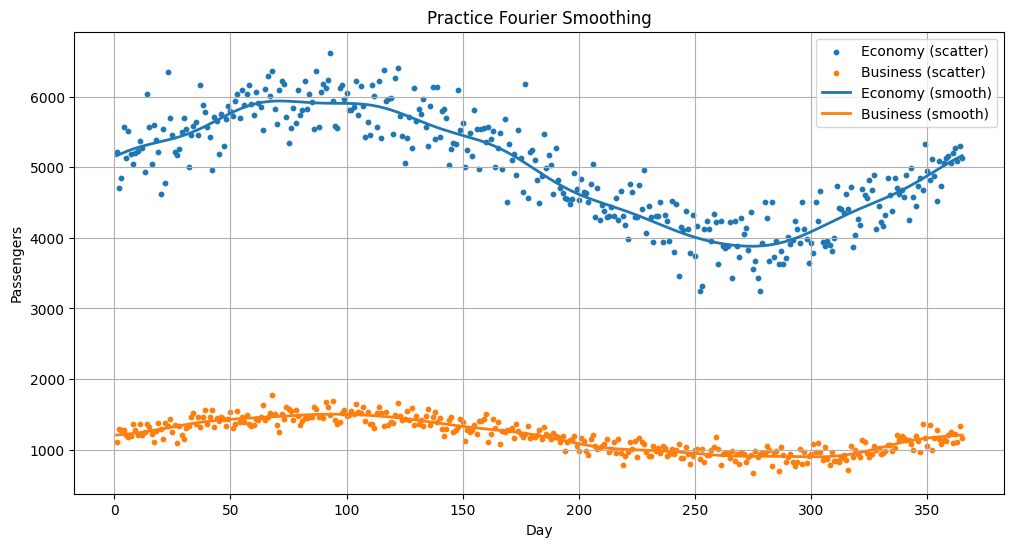

In [10]:
import numpy as np

def scrfft(xdata,ydata):
    sdata=np.argsort(xdata)
    xdatas=xdata[sdata]
    ydatas=ydata[sdata]
    
    xmin=np.min(xdata)
    xmax=np.max(xdata)
    ndata=len(xdata)
    x=(xmax-xmin)/(ndata-1)*np.arange(ndata)+xmin
    y=np.interp(x,xdatas,ydatas)
    
    yf = 2.0*np.fft.rfft(y)/(ndata+1)
    a=np.real(yf)
    b=-np.imag(yf)
    
    a[0]=0.5*a[0]
    
    f=np.arange(len(a))/(xmax-xmin)
    
    return(f, a, b)

# Create X axis (days)
x_axis_data = np.arange(1, 366)  # 1 year
print(x_axis_data)
# Create fake passenger data (realistic pattern)
y_std = 5000 + 1000 * np.sin(2 * np.pi * np.array(x_axis_data) / 365) \
              + 300 * np.random.randn(len(x_axis_data))

y_bus = 1200 + 300 * np.sin(2 * np.pi * np.array(x_axis_data) / 365) \
              + 100 * np.random.randn(len(x_axis_data))


# Apply Fourier
f_std, a_std, b_std = scrfft(x_axis_data, y_std)
f_bus, a_bus, b_bus = scrfft(x_axis_data, y_bus)


def reconstruct_signal(x_axis_data, f, a, b, n_terms=8):
    y_smooth = np.zeros(len(x_axis_data))
    
    for k in range(n_terms):
        y_smooth += a[k] * np.cos(2 * np.pi * f[k] * np.array(x_axis_data)) \
                  + b[k] * np.sin(2 * np.pi * f[k] * np.array(x_axis_data))
    
    return y_smooth

# Correct usage
y_std_smooth = reconstruct_signal(x_axis_data, f_std, a_std, b_std)
y_bus_smooth = reconstruct_signal(x_axis_data, f_bus, a_bus, b_bus)


import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Scatter
plt.scatter(x_axis_data, y_std, s=10, label='Economy (scatter)')
plt.scatter(x_axis_data, y_bus, s=10, label='Business (scatter)')

# Smooth
plt.plot(x_axis_data, y_std_smooth, linewidth=2, label='Economy (smooth)')
plt.plot(x_axis_data, y_bus_smooth, linewidth=2, label='Business (smooth)')

plt.xlabel("Day")
plt.ylabel("Passengers")
plt.title("Practice Fourier Smoothing")

plt.legend()
plt.grid()

plt.show()

In [15]:
print(np.arange(3))

[0 1 2]


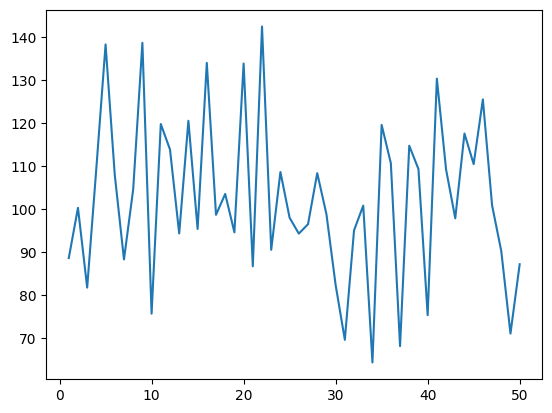

In [49]:
import numpy as np
import matplotlib.pyplot as plt
days = np.arange(1,51)
passengers = 100 + 20 * np.random.randn(len(days))
plt.plot(days,passengers)
plt.show()

[104.15823382 108.13473286 111.75570505 114.86289651 117.32050808
 119.02113033 119.89043791 119.89043791 119.02113033 117.32050808
 114.86289651 111.75570505 108.13473286 104.15823382 100.
  95.84176618  91.86526714  88.24429495  85.13710349  82.67949192
  80.97886967  80.10956209  80.10956209  80.97886967  82.67949192
  85.13710349  88.24429495  91.86526714  95.84176618 100.
 104.15823382 108.13473286 111.75570505 114.86289651 117.32050808
 119.02113033 119.89043791 119.89043791 119.02113033 117.32050808
 114.86289651 111.75570505 108.13473286 104.15823382 100.
  95.84176618  91.86526714  88.24429495  85.13710349  82.67949192
  80.97886967  80.10956209  80.10956209  80.97886967  82.67949192
  85.13710349  88.24429495  91.86526714  95.84176618 100.
 104.15823382 108.13473286 111.75570505 114.86289651 117.32050808
 119.02113033 119.89043791 119.89043791 119.02113033 117.32050808
 114.86289651 111.75570505 108.13473286 104.15823382 100.
  95.84176618  91.86526714  88.24429495  85.137103

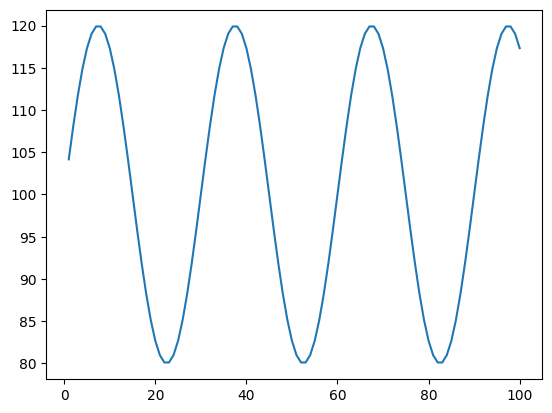

In [50]:
import numpy as np
import matplotlib.pyplot as plt

days = np.arange(1, 101)
passengers = 100 + 20 * np.sin(2 * np.pi * days / 30)
print(passengers)
plt.plot(days, passengers)
plt.show()

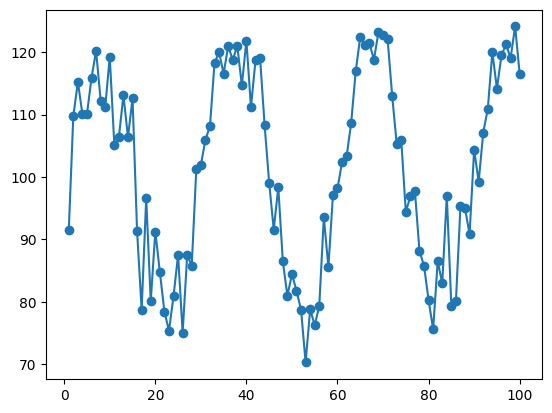

In [52]:
import numpy as np
import matplotlib.pyplot as plt

days = np.arange(1, 101)
passengers = 100 + 20 * np.sin(2 * np.pi * days / 30) + 5 * np.random.randn(len(days))

plt.scatter(days, passengers)
plt.plot(days, passengers)
plt.show()